# Testing EllipsePhantom

### Import

In [1]:
import torch

from mrpro.data import SpatialDimension
from mrpro.phantoms.phantom_elements import EllipseParameters
from  mrpro.phantoms import EllipsePhantom 
import matplotlib.pyplot as plt

In [2]:
# Default ellipses
phantom = EllipsePhantom()

# Custom ellipses
custom_ellipses = [
    EllipseParameters(center_x=0.3, center_y=0.3, radius_x=0.15, radius_y=0.2, intensity=1.5),
    EllipseParameters(center_x=-0.3, center_y=-0.3, radius_x=0.2, radius_y=0.1, intensity=3.0)
]
custom_phantom = EllipsePhantom(ellipses=custom_ellipses)


In [3]:
# Define k-space grid
nx, ny = 256, 256
kx = torch.linspace(-nx // 2, nx // 2 - 1, nx)
ky = torch.linspace(-ny // 2, ny // 2 - 1, ny)
kx, ky = torch.meshgrid(kx, ky, indexing='xy')

# Generate k-space data
kspace_data = phantom.kspace(ky, kx)


In [4]:
# Generate image space data
image_dimensions = SpatialDimension(z=1, y=256, x=256)
image_data = phantom.image_space(image_dimensions)


### Display

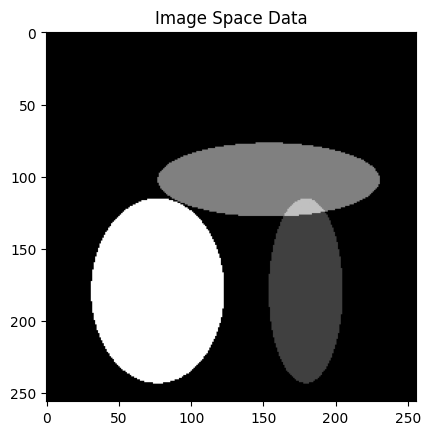

In [5]:
plt.imshow(image_data[0, 0, 0, :, :].abs().numpy(), cmap='gray')
plt.title('Image Space Data')
plt.show()